In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [4]:
results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [6]:
key_funds = (
    nav["amfi_code"]
    .value_counts()
    .head(5)
    .index
)

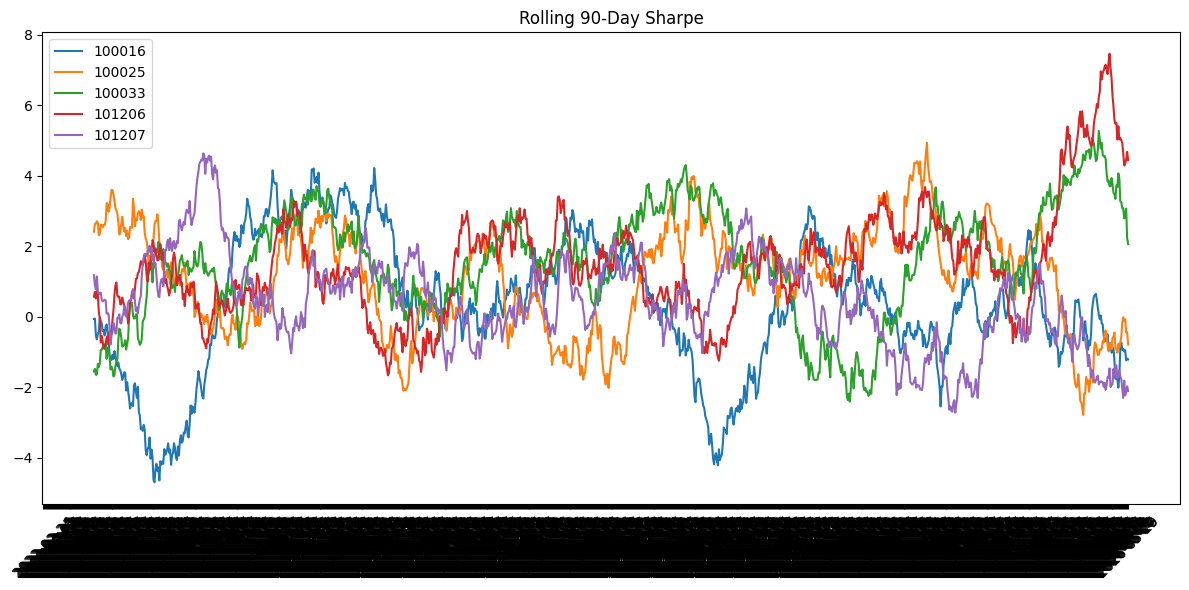

In [7]:
plt.figure(figsize=(12,6))

for fund in key_funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [8]:
tx = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

In [9]:
tx["cohort_year"] = (
    tx.groupby("investor_id")
      ["transaction_date"]
      .transform("min")
      .dt.year
)

In [10]:
cohort = (
    tx.groupby("cohort_year")
      .agg(
          avg_sip_amount=("amount_inr","mean"),
          total_invested=("amount_inr","sum")
      )
)

cohort

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [11]:
sip = tx[
    tx["transaction_type"] == "SIP"
].copy()

In [12]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

In [13]:
continuity = (
    sip.groupby("investor_id")
       .agg(
           sip_count=("transaction_date","count"),
           avg_gap=("gap_days","mean")
       )
)

continuity = continuity[
    continuity["sip_count"] >= 6
]

continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


In [14]:
holdings = pd.read_csv(
    "../data/processed/holdings_clean.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [15]:
hhi = (
    holdings.groupby("amfi_code")
            ["weight_pct"]
            .apply(
                lambda x:
                np.sum((x/100)**2)
            )
            .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [16]:
hhi.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)